MODEL TRAINING:

In [60]:
#Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [61]:
# Load ML-ready data

ml_data = pd.read_csv("../data/cleaned/epl-ml-ready.csv")

features = [
    "PrevPos",
    "PrevPts",
    "PrevGD",
    "PrevGF",
    "PrevGA",
    "PrevWinPct",
    "PrevDrawPct",
    "PrevLossPct"
]

x = ml_data[["PrevWinPct", "PrevDrawPct", "PrevLossPct", "PrevGF", "PrevGA", "PrevGD"]]
y = ml_data["Pos"]

print(x.head())
print(y.head())

   PrevWinPct  PrevDrawPct  PrevLossPct  PrevGF  PrevGA  PrevGD
0    0.526316     0.263158     0.210526    63.0    38.0    25.0
1    0.684211     0.236842     0.078947    79.0    36.0    43.0
2    0.605263     0.236842     0.157895    85.0    42.0    43.0
3    0.684211     0.315789     0.000000    73.0    26.0    47.0
4    0.657895     0.210526     0.131579    87.0    36.0    51.0
0    1
1    2
2    1
3    2
4    4
Name: Pos, dtype: int64


In [62]:
# Train/test split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

Model 1: Linear Regression

In [63]:
# Model 1: Linear Regression

linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

linear_predictions = linear_model.predict(x_test).round().clip(1, 20)

linear_mae = mean_absolute_error(y_test, linear_predictions)

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 2.8241758241758244


Model 2: Random Forest

In [64]:
# Model 2: Random Forest

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

rf_predictions = rf_model.predict(x_test).round().clip(1, 20)

rf_mae = mean_absolute_error(y_test, rf_predictions)


print("Random Forest MAE:", rf_mae)

Random Forest MAE: 3.0


In [65]:
# Compare actual vs predicted

comparison = pd.DataFrame({
    "Actual Position": y_test,
    "Predicted Position": rf_predictions
}).reset_index(drop=True)

comparison["Error"] = abs(
    comparison["Actual Position"] - comparison["Predicted Position"]
)

print(comparison.head(20))

    Actual Position  Predicted Position  Error
0                10                14.0    4.0
1                17                16.0    1.0
2                 8                 6.0    2.0
3                17                15.0    2.0
4                11                12.0    1.0
5                 1                 3.0    2.0
6                 4                 2.0    2.0
7                13                13.0    0.0
8                14                15.0    1.0
9                 6                11.0    5.0
10               12                11.0    1.0
11                8                 7.0    1.0
12               20                18.0    2.0
13                9                10.0    1.0
14                7                12.0    5.0
15               10                10.0    0.0
16               12                15.0    3.0
17                3                 3.0    0.0
18               14                10.0    4.0
19               15                15.0    0.0


Visualise predictions

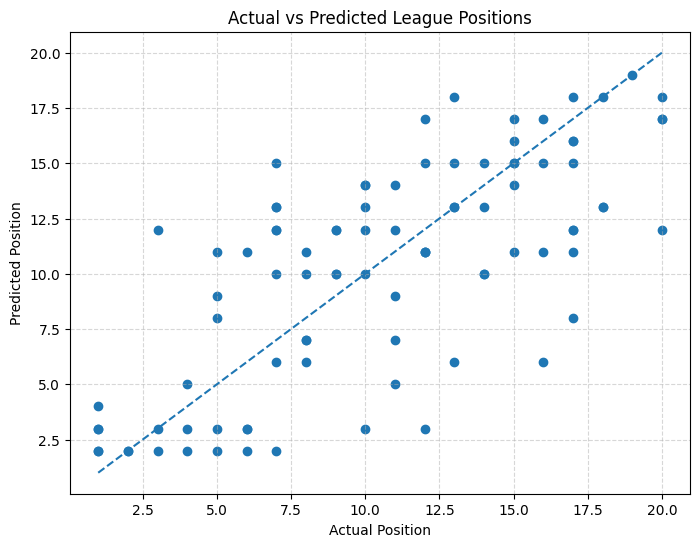

In [66]:
# Visualise predictions

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)
plt.plot([1, 20], [1, 20], linestyle="--")

plt.title("Actual vs Predicted League Positions")
plt.xlabel("Actual Position")
plt.ylabel("Predicted Position")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [67]:
# Save best model

joblib.dump(rf_model, "../models/epl_random_forest_model.pkl")

print("Model saved.")

Model saved.


Model Comparison

In [68]:
# Compare model performance

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae]
})

model_results = model_results.sort_values(by="MAE", ascending=True)

print(model_results)

               Model       MAE
0  Linear Regression  2.824176
1      Random Forest  3.000000


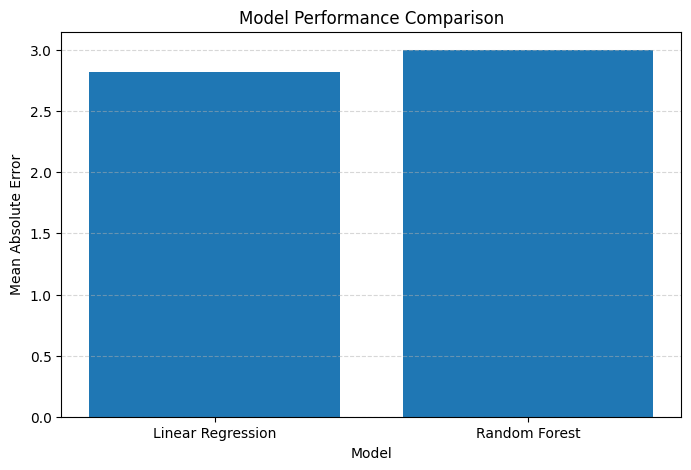

               Model       MAE
0  Linear Regression  2.824176
1      Random Forest  3.000000


In [69]:
# Plot model comparison

plt.figure(figsize=(8,5))

plt.bar(model_results["Model"], model_results["MAE"])

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae]
})

model_results = model_results.sort_values(
    by="MAE",
    ascending=True
)
print(model_results)